In [1]:
import warnings
warnings.filterwarnings("ignore")

import zipfile
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageOps

from sklearn.datasets import fetch_lfw_people, fetch_olivetti_faces
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
np.set_printoptions(precision=3, suppress=True)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
HOLLYWOOD_ZIP_PATH = Path("/content/drive/MyDrive/LogicMojo/archive.zip")
IMAGE_SIZE = (64, 64)
MAX_IMAGES_PER_CLASS = 100
RANDOM_SEED = 42


def pil_to_square_grayscale_array(pil_img, image_size=IMAGE_SIZE):
    """Convert a PIL image to a centered square grayscale float array in [0, 1]."""
    pil_img = ImageOps.exif_transpose(pil_img)
    pil_img = pil_img.convert("L")
    width, height = pil_img.size
    side = min(width, height)
    left = (width - side) // 2
    top = (height - side) // 2
    pil_img = pil_img.crop((left, top, left + side, top + side))
    pil_img = pil_img.resize(image_size, Image.Resampling.LANCZOS)
    return np.asarray(pil_img, dtype=np.float32) / 255.0


def load_hollywood_faces(zip_path=HOLLYWOOD_ZIP_PATH, image_size=IMAGE_SIZE, max_images_per_class=MAX_IMAGES_PER_CLASS):
    if not zip_path.exists():
        raise FileNotFoundError(f"Dataset zip not found: {zip_path}")

    images = []
    targets = []
    filenames = []
    skipped = []

    with zipfile.ZipFile(zip_path) as z:
        image_names = [
            name for name in z.namelist()
            if not name.endswith("/") and name.lower().endswith((".jpg", ".jpeg", ".png")) and "/" in name
        ]
        class_names = sorted({name.split("/")[0] for name in image_names})
        class_to_id = {class_name: idx for idx, class_name in enumerate(class_names)}

        rng = np.random.default_rng(RANDOM_SEED)
        for class_name in class_names:
            class_files = [name for name in image_names if name.split("/")[0] == class_name]
            class_files = sorted(class_files)
            if max_images_per_class is not None and len(class_files) > max_images_per_class:
                class_files = sorted(rng.choice(class_files, size=max_images_per_class, replace=False))

            for file_name in class_files:
                try:
                    with z.open(file_name) as file_obj:
                        pil_img = Image.open(file_obj)
                        arr = pil_to_square_grayscale_array(pil_img, image_size=image_size)
                    images.append(arr)
                    targets.append(class_to_id[class_name])
                    filenames.append(file_name)
                except Exception as e:
                    skipped.append((file_name, str(e)))

    images = np.stack(images)
    data = images.reshape(images.shape[0], -1)
    target = np.array(targets, dtype=int)
    target_names = np.array(class_names)

    # Shuffle once so early grids do not show only the first celebrity.
    rng = np.random.default_rng(RANDOM_SEED)
    order = rng.permutation(len(target))

    faces = SimpleNamespace(
        data=data[order],
        images=images[order],
        target=target[order],
        target_names=target_names,
        filenames=np.array(filenames, dtype=object)[order],
        DESCR="Hollywood Celebrity Facial Recognition Dataset loaded from local archive.zip"
    )
    return faces, skipped


def load_face_dataset():
    try:
        faces, skipped = load_hollywood_faces()
        dataset_name = "Hollywood Celebrity Facial Recognition Dataset"
        image_shape = faces.images.shape[1:]
        if skipped:
            print(f"Skipped {len(skipped)} unreadable files. First skipped item:", skipped[0])
        return faces, dataset_name, image_shape
    except Exception as e:
        print("Could not load the local Hollywood celebrity dataset.")
        print("Reason:", e)
        print("Trying LFW as fallback...")

    try:
        faces = fetch_lfw_people(
            min_faces_per_person=60,
            resize=0.4,
            color=False,
            funneled=True,
            download_if_missing=True
        )
        dataset_name = "Labeled Faces in the Wild (LFW) fallback"
        image_shape = faces.images.shape[1:]
        return faces, dataset_name, image_shape
    except Exception as e:
        print("Could not load LFW. Falling back to Olivetti faces.")
        print("Reason:", e)
        faces = fetch_olivetti_faces(shuffle=True, random_state=42, download_if_missing=True)
        dataset_name = "Olivetti faces fallback"
        image_shape = faces.images.shape[1:]
        faces.target_names = np.array([f"person_{i:02d}" for i in range(40)])
        return faces, dataset_name, image_shape


faces, dataset_name, image_shape = load_face_dataset()

print("Dataset:", dataset_name)
print("Images shape:", faces.images.shape)
print("Data matrix shape:", faces.data.shape)
print("Target shape:", faces.target.shape)
print("Image shape:", image_shape)
print("Number of classes:", len(faces.target_names))
print("Class names:", faces.target_names)



Dataset: Hollywood Celebrity Facial Recognition Dataset
Images shape: (1700, 64, 64)
Data matrix shape: (1700, 4096)
Target shape: (1700,)
Image shape: (64, 64)
Number of classes: 17
Class names: ['Angelina Jolie' 'Brad Pitt' 'Denzel Washington' 'Hugh Jackman'
 'Jennifer Lawrence' 'Johnny Depp' 'Kate Winslet' 'Leonardo DiCaprio'
 'Megan Fox' 'Natalie Portman' 'Nicole Kidman' 'Robert Downey Jr'
 'Sandra Bullock' 'Scarlett Johansson' 'Tom Cruise' 'Tom Hanks'
 'Will Smith']


### Flattening an Image
Row 1 data Row 2 data Row 3 data.. Row n data

In [6]:
faces.data.shape

(1700, 4096)

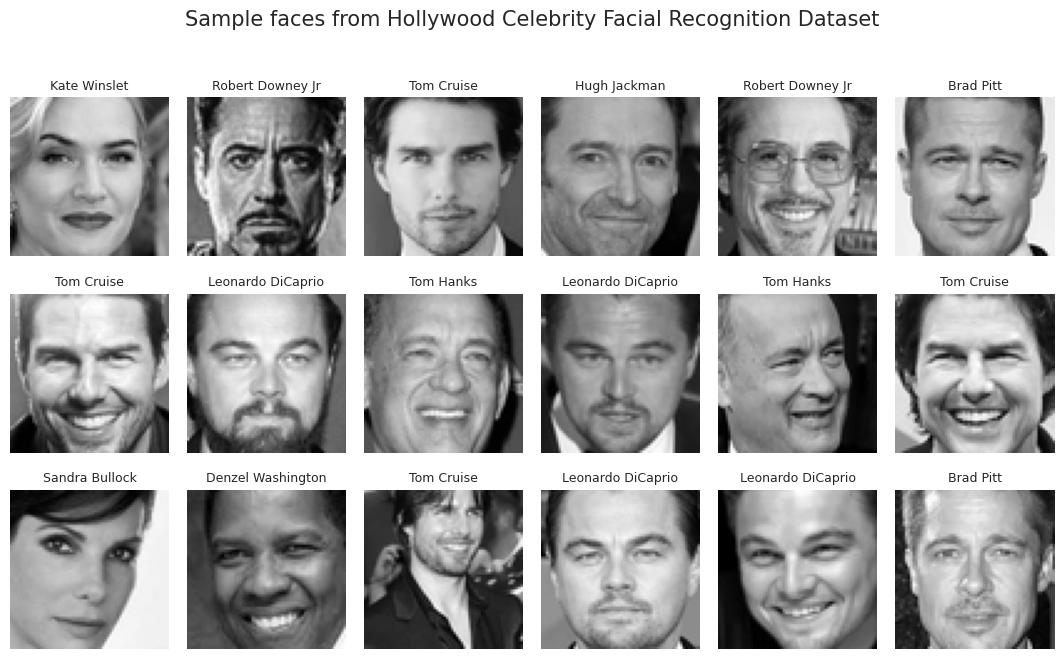

In [7]:
def show_face_grid(images, labels=None, names=None, n_rows=3, n_cols=6, title="Face examples", cmap="gray"):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.8*n_cols, 2.2*n_rows))
    axes = np.asarray(axes).ravel()
    for i, ax in enumerate(axes):
        ax.imshow(images[i], cmap=cmap)
        ax.axis("off")
        if labels is not None and names is not None:
            ax.set_title(str(names[labels[i]]), fontsize=9)
    fig.suptitle(title, y=1.02, fontsize=15)
    plt.tight_layout()
    plt.show()

show_face_grid(faces.images, faces.target, faces.target_names, n_rows=3, n_cols=6, title=f"Sample faces from {dataset_name}")

In [8]:
class_counts = pd.Series(faces.target).map(lambda idx: faces.target_names[idx]).value_counts().sort_index()

print("Number of classes:", len(class_counts))
print("Minimum images per class:", class_counts.min())
print("Maximum images per class:", class_counts.max())


Number of classes: 17
Minimum images per class: 100
Maximum images per class: 100


Take the mean of the dataset

Person: Kate Winslet
Image shape: (64, 64)
Minimum pixel value: 0.13725491
Maximum pixel value: 0.9019608


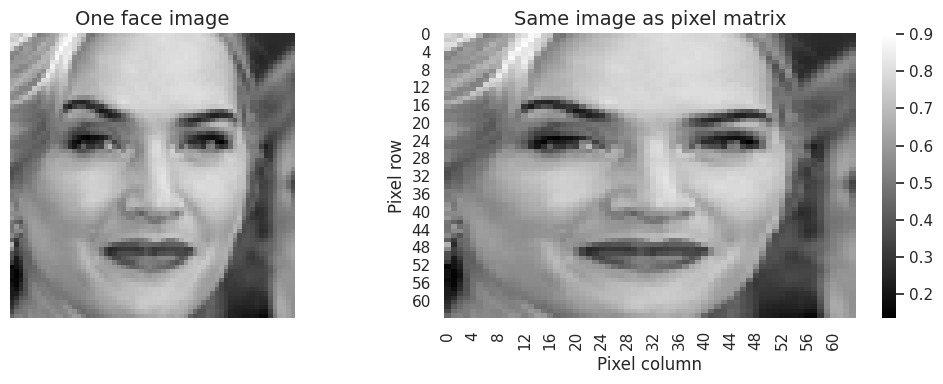

In [9]:
image_index = 0
one_image = faces.images[image_index]
one_label = faces.target[image_index]

print("Person:", faces.target_names[one_label])
print("Image shape:", one_image.shape)
print("Minimum pixel value:", one_image.min())
print("Maximum pixel value:", one_image.max())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(one_image, cmap="gray")
axes[0].set_title("One face image")
axes[0].axis("off")

sns.heatmap(one_image, cmap="gray", cbar=True, ax=axes[1])
axes[1].set_title("Same image as pixel matrix")
axes[1].set_xlabel("Pixel column")
axes[1].set_ylabel("Pixel row")
plt.tight_layout()
plt.show()


In [11]:
X = faces.data.astype(np.float64)
y = faces.target.astype(int)

names = faces.target_names

m, n = X.shape
h, w = image_shape

print("X shape:", X.shape)
print("m = number of images:", m)
print("n = number of pixel features:", n)
print("h x w:", h, "x", w, "=", h*w)
print("y shape:", y.shape)

pd.DataFrame({
    "meaning": ["rows", "columns", "target values"],
    "shape/value": [m, n, y.shape[0]],
    "interpretation": ["face images", "pixel features", "person labels"]
})


X shape: (1700, 4096)
m = number of images: 1700
n = number of pixel features: 4096
h x w: 64 x 64 = 4096
y shape: (1700,)


,meaning,shape/value,interpretation
0,rows,1700,face images
1,columns,4096,pixel features
2,target values,1700,person labels


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

train_counts = pd.Series(y_train).map(lambda idx: names[idx]).value_counts()
test_counts = pd.Series(y_test).map(lambda idx: names[idx]).value_counts()
pd.DataFrame({"train_count": train_counts, "test_count": test_counts})


X_train shape: (1275, 4096)
X_test shape: (425, 4096)
y_train shape: (1275,)
y_test shape: (425,)


,train_count,test_count
Angelina Jolie,75,25
Brad Pitt,75,25
Denzel Washington,75,25
Hugh Jackman,75,25
Jennifer Lawrence,75,25
Johnny Depp,75,25
Kate Winslet,75,25
Leonardo DiCaprio,75,25
Megan Fox,75,25
Natalie Portman,75,25


X_train shape: (1275, 4096)
mean_face shape: (4096,)


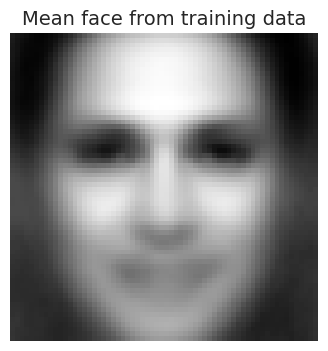

In [27]:
mean_face = X_train.mean(axis=0)

print("X_train shape:", X_train.shape)
print("mean_face shape:", mean_face.shape)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(mean_face.reshape(image_shape), cmap="gray")
ax.set_title("Mean face from training data")
ax.axis("off")
plt.show()

Original vector shape: (4096,)
Mean vector shape: (4096,)
Centered vector shape: (4096,)


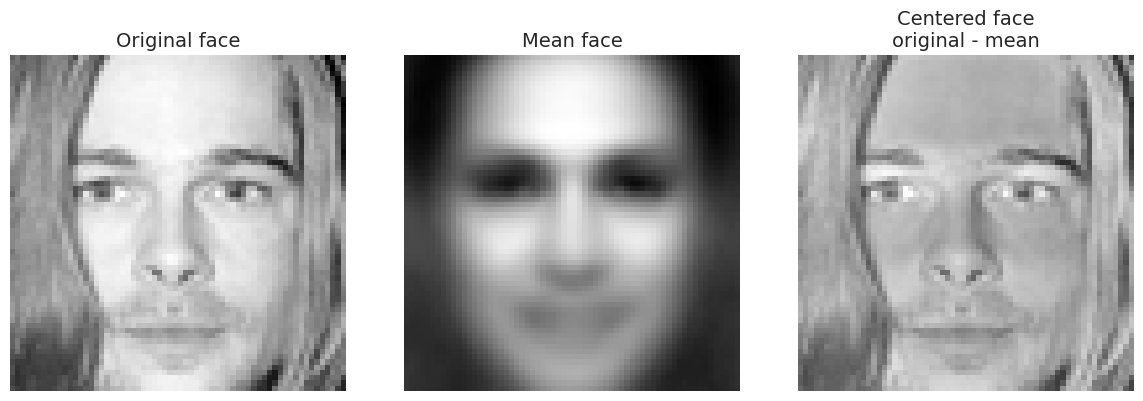

In [28]:
idx = 14
centered_one = X_train[idx] - mean_face

print("Original vector shape:", X_train[idx].shape)
print("Mean vector shape:", mean_face.shape)
print("Centered vector shape:", centered_one.shape)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(X_train[idx].reshape(image_shape), cmap="gray")
axes[0].set_title("Original face")
axes[0].axis("off")

axes[1].imshow(mean_face.reshape(image_shape), cmap="gray")
axes[1].set_title("Mean face")
axes[1].axis("off")

vmax = np.max(np.abs(centered_one))
axes[2].imshow(centered_one.reshape(image_shape), cmap="gray", vmin=-vmax, vmax=vmax)
axes[2].set_title("Centered face\noriginal - mean")
axes[2].axis("off")

plt.tight_layout()
plt.show()


In [29]:
n_components_for_demo = 600
pca = PCA(n_components=n_components_for_demo, whiten=False, random_state=42)
pca.fit(X_train)



PCA(n_components=600, random_state=42)

In [37]:
# pca.components_.shape
pca.components_[0].shape
# pca.get_covariance().shape

(4096,)

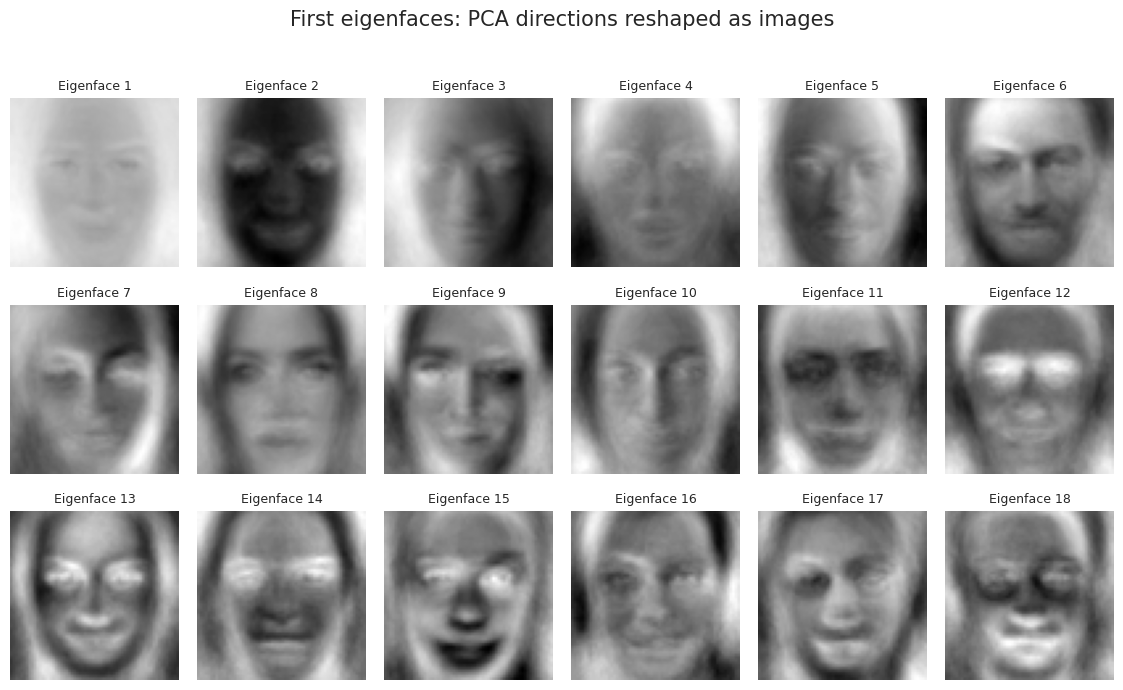

In [43]:
# each component is a face of 64 x 64
def show_eigenfaces(pca_model, image_shape, n_rows=3, n_cols=6):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.9*n_cols, 2.3*n_rows))
    axes = np.asarray(axes).ravel()
    for i, ax in enumerate(axes):
        component = pca_model.components_[i]
        vmax = np.max(np.abs(component))
        ax.imshow(component.reshape(image_shape), cmap="gray", vmin=-vmax, vmax=vmax)
        ax.set_title(f"Eigenface {i+1}", fontsize=9)
        ax.axis("off")
    fig.suptitle("First eigenfaces: PCA directions reshaped as images", y=1.02, fontsize=15)
    plt.tight_layout()
    plt.show()

show_eigenfaces(pca, image_shape, n_rows=3, n_cols=6)

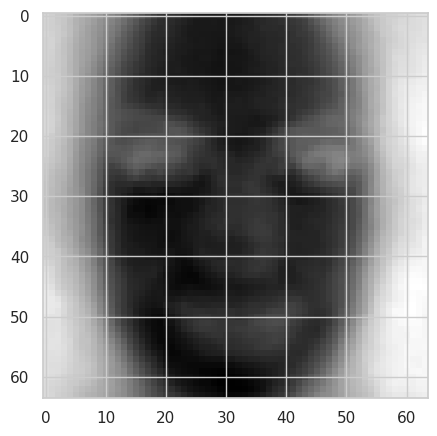

In [42]:
comp1 = pca.components_[1].reshape(64, 64)
plt.imshow(comp1, cmap='gray')
plt.show()

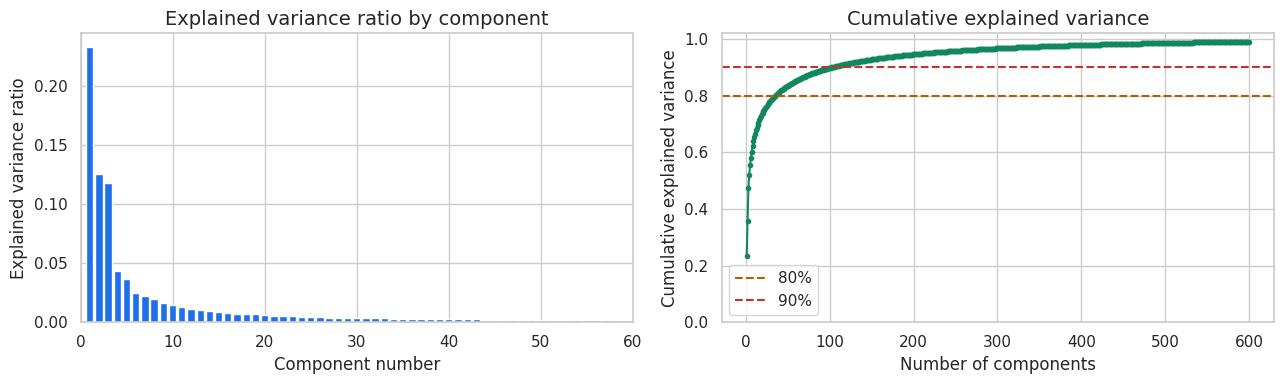

Components needed for 70% variance: 15
Components needed for 80% variance: 36
Components needed for 90% variance: 103
Components needed for 95% variance: 216


In [48]:
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(np.arange(1, len(explained)+1), explained, color="#1f6feb")
axes[0].set_title("Explained variance ratio by component")
axes[0].set_xlabel("Component number")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_xlim(0, min(60, len(explained)))

axes[1].plot(np.arange(1, len(cumulative)+1), cumulative, marker="o", markersize=3, color="#11875d")
axes[1].axhline(0.80, color="#b85c00", linestyle="--", label="80%")
axes[1].axhline(0.90, color="#c3342f", linestyle="--", label="90%")
axes[1].set_title("Cumulative explained variance")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_ylim(0, 1.02)
axes[1].legend()
plt.tight_layout()
plt.show()

for threshold in [0.70, 0.80, 0.90, 0.95]:
    if cumulative[-1] >= threshold:
        k = np.argmax(cumulative >= threshold) + 1
        print(f"Components needed for {threshold:.0%} variance: {k}")
    else:
        print(f"{threshold:.0%} variance not reached with {len(cumulative)} components")


X_mean - 3 * sqrt(lambda1), X_mean, X_mean + 3 * sqrt(lambda1)

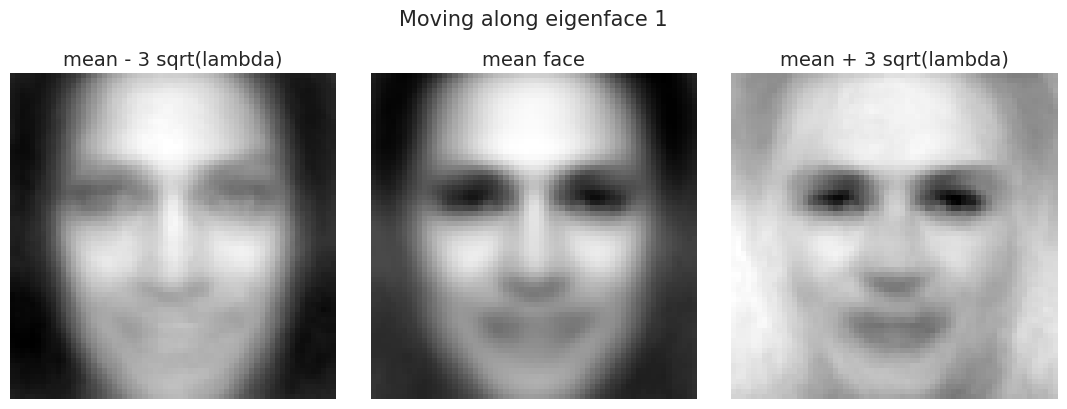

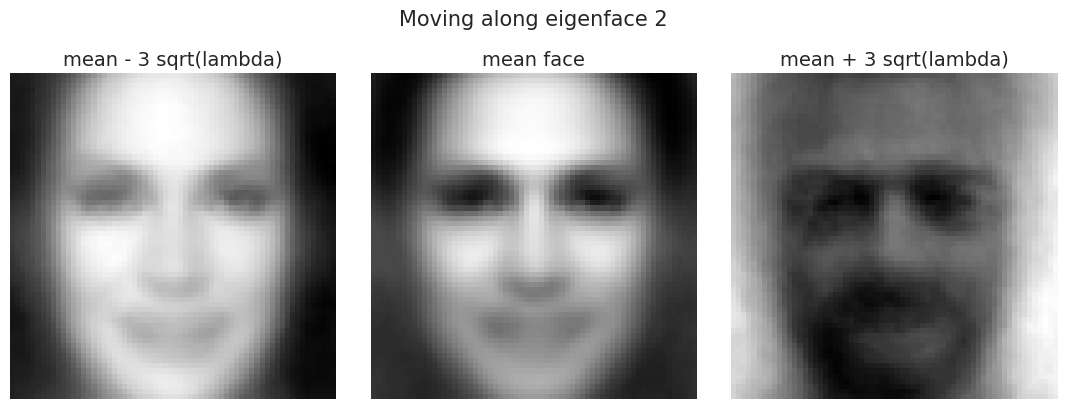

In [50]:
def show_component_variation(pca_model, component_index, image_shape, scale=3.0):
    component = pca_model.components_[component_index]
    amount = scale * np.sqrt(pca_model.explained_variance_[component_index])
    images = [pca_model.mean_ - amount * component, pca_model.mean_, pca_model.mean_ + amount * component]
    titles = [f"mean - {scale:g} sqrt(lambda)", "mean face", f"mean + {scale:g} sqrt(lambda)"]
    fig, axes = plt.subplots(1, 3, figsize=(11, 4))
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img.reshape(image_shape), cmap="gray")
        ax.set_title(title)
        ax.axis("off")
    fig.suptitle(f"Moving along eigenface {component_index+1}", y=1.02, fontsize=15)
    plt.tight_layout()
    plt.show()

show_component_variation(pca, component_index=0, image_shape=image_shape, scale=3.0)
show_component_variation(pca, component_index=1, image_shape=image_shape, scale=3.0)


In [51]:
Z_train = pca.transform(X_train)
Z_test = pca.transform(X_test)

Z_train.shape, Z_test.shape

((1275, 600), (425, 600))

In [52]:
pd.DataFrame(Z_train[:5, :8], columns=[f"PC{i}" for i in range(1, 9)])

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,5.888088,0.052902,4.713229,-2.163112,-1.640441,-0.473409,1.238148,-0.555085
1,9.484154,-1.936801,-4.233010,0.876005,1.859654,-2.209182,0.211884,1.584376
2,1.258282,10.473221,0.977414,1.025667,-1.368124,-0.622655,3.121518,-0.921788
3,-4.906202,3.421522,-6.969287,-0.118564,4.430881,0.971313,0.303915,2.224249
4,-2.464509,1.436988,-5.890238,-2.262700,4.872125,0.236519,1.097358,-1.703334


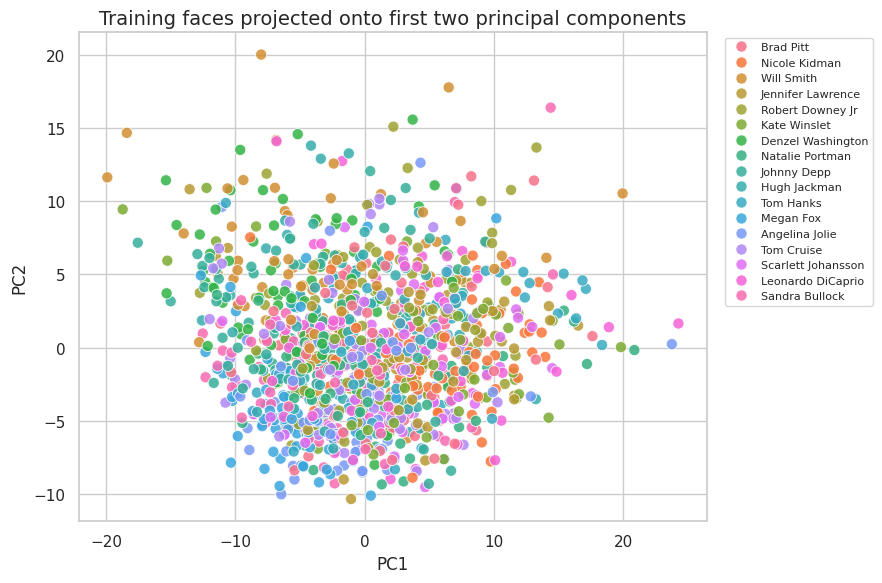

In [53]:
plot_df = pd.DataFrame({
    "PC1": Z_train[:, 0],
    "PC2": Z_train[:, 1],
    "person": [names[i] for i in y_train]
})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="person", s=65, alpha=0.85)
plt.title("Training faces projected onto first two principal components")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


# Reconstruct
X_hat = Z @ W_k.T + X_mean

In [56]:
def reconstruct_with_k(pca_model, X_input, k):
    Z = pca_model.transform(X_input)[:, :k]
    W = pca_model.components_[:k]
    X_hat = Z @ W + pca_model.mean_
    return X_hat

Test person: Hugh Jackman


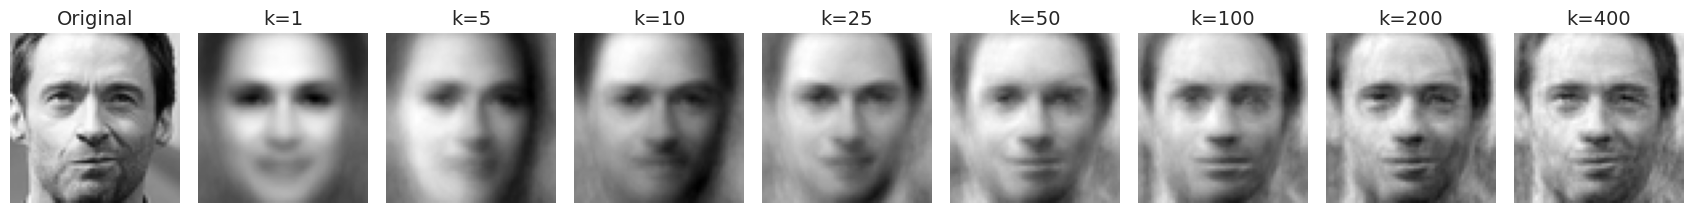

In [63]:
def show_reconstruction_progress(pca_model, image_vector, image_shape, k_values):
    reconstructions = [reconstruct_with_k(pca_model, image_vector.reshape(1, -1), k)[0] for k in k_values]
    n_cols = len(k_values) + 1
    fig, axes = plt.subplots(1, n_cols, figsize=(1.9*n_cols, 3.2))
    axes[0].imshow(image_vector.reshape(image_shape), cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")
    for ax, recon, k in zip(axes[1:], reconstructions, k_values):
        ax.imshow(recon.reshape(image_shape), cmap="gray")
        ax.set_title(f"k={k}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

sample_test_index = 300
k_values = [1, 5, 10, 25, 50, 100, 200, min(400, pca.n_components_)]
k_values = sorted(set(k for k in k_values if k <= pca.n_components_))

print("Test person:", names[y_test[sample_test_index]])
show_reconstruction_progress(pca, X_test[sample_test_index], image_shape, k_values)

In [67]:
def reconstruction_mse(X_original, X_reconstructed):
    return np.mean((X_original - X_reconstructed) ** 2)

In [68]:
candidate_k = [1, 2, 5, 10, 15, 25, 40, 60, 80, 100, 125, 150, 200, 400]
candidate_k = [k for k in candidate_k if k <= pca.n_components_]
errors = []
for k in candidate_k:
    X_test_reconstructed = reconstruct_with_k(pca, X_test, k)
    errors.append(reconstruction_mse(X_test, X_test_reconstructed))

error_df = pd.DataFrame({"k_components": candidate_k, "test_reconstruction_mse": errors})
error_df

,k_components,test_reconstruction_mse
0,1,0.035355
1,2,0.029098
2,5,0.020808
3,10,0.016424
4,15,0.014048
5,25,0.011479
6,40,0.009509
7,60,0.007930
8,80,0.006844
9,100,0.006083


4096 feats -> K =1, 1 feature
Compression ratio = 4096/1 = 4096
K = 400
Compression ratio = 4096/400 = 10.24


In [69]:
recognition_k = 200
Z_train_k = Z_train[:, :recognition_k]
Z_test_k = Z_test[:, :recognition_k]

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Z_train_k, y_train)
y_pred = knn.predict(Z_test_k)

print("PCA components used:", recognition_k)
print("Recognition accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=names))

PCA components used: 200
Recognition accuracy: 0.33647058823529413
                    precision    recall  f1-score   support

    Angelina Jolie       0.29      0.36      0.32        25
         Brad Pitt       0.20      0.48      0.29        25
 Denzel Washington       0.31      0.60      0.41        25
      Hugh Jackman       0.20      0.12      0.15        25
 Jennifer Lawrence       0.31      0.36      0.33        25
       Johnny Depp       1.00      0.12      0.21        25
      Kate Winslet       0.36      0.16      0.22        25
 Leonardo DiCaprio       0.43      0.36      0.39        25
         Megan Fox       0.64      0.56      0.60        25
   Natalie Portman       0.38      0.12      0.18        25
     Nicole Kidman       0.33      0.60      0.42        25
  Robert Downey Jr       0.60      0.12      0.20        25
    Sandra Bullock       0.59      0.52      0.55        25
Scarlett Johansson       0.15      0.20      0.17        25
        Tom Cruise       0.47   

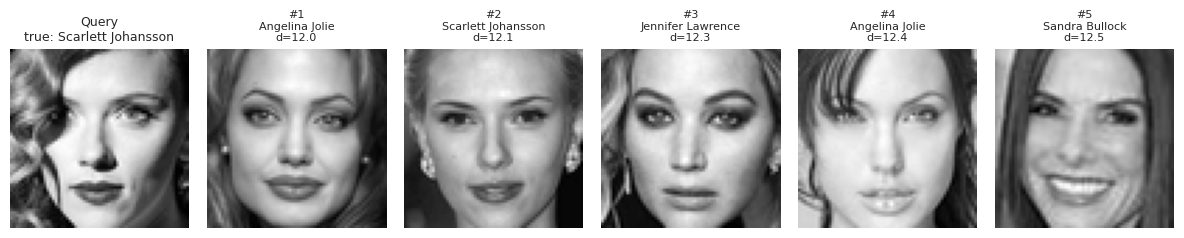

In [72]:
def show_nearest_matches(query_index, Z_train_features, Z_test_features, X_train, X_test, y_train, y_test, names, image_shape, n_neighbors=5):
    nn = NearestNeighbors(n_neighbors=n_neighbors, metric="euclidean")
    nn.fit(Z_train_features)
    distances, indices = nn.kneighbors(Z_test_features[query_index].reshape(1, -1))
    distances = distances[0]
    indices = indices[0]

    fig, axes = plt.subplots(1, n_neighbors + 1, figsize=(2.0*(n_neighbors+1), 3.2))
    axes[0].imshow(X_test[query_index].reshape(image_shape), cmap="gray")
    axes[0].set_title(f"Query\ntrue: {names[y_test[query_index]]}", fontsize=9)
    axes[0].axis("off")

    for rank, (dist, train_idx) in enumerate(zip(distances, indices), start=1):
        axes[rank].imshow(X_train[train_idx].reshape(image_shape), cmap="gray")
        axes[rank].set_title(f"#{rank}\n{names[y_train[train_idx]]}\nd={dist:.1f}", fontsize=8)
        axes[rank].axis("off")

    plt.tight_layout()
    plt.show()

show_nearest_matches(150, Z_train_k, Z_test_k, X_train, X_test, y_train, y_test, names, image_shape, n_neighbors=5)
# show_nearest_matches(1, Z_train_k, Z_test_k, X_train, X_test, y_train, y_test, names, image_shape, n_neighbors=5)


In [73]:
raw_knn = KNeighborsClassifier(n_neighbors=5)
raw_knn.fit(X_train, y_train)
raw_pred = raw_knn.predict(X_test)
raw_accuracy = accuracy_score(y_test, raw_pred)

pca_accuracy = accuracy_score(y_test, y_pred)

comparison = pd.DataFrame({
    "representation": ["Raw pixels", f"PCA features (k={recognition_k})"],
    "dimension_per_face": [X_train.shape[1], recognition_k],
    "accuracy": [raw_accuracy, pca_accuracy]
})
comparison


,representation,dimension_per_face,accuracy
0,Raw pixels,4096,0.336471
1,PCA features (k=200),200,0.336471


1. X => m x n
2. find mean of the dataset
3. Xc = X - mean => m x n
4. Find covariance => Xc.T x Xc => n x n
5. Find eigen values and vectors (fit)
    1. Eigen values = n
    2. Eignen vectors W = n x n
6. Choose k
7. Get Wk => n x k
8. Project = Xc x Wk (transform)